# Prédiction du churn client et identification des profils à risque

## Contexte métier

Dans le secteur des télécommunications, le churn client représente un enjeu majeur, car la perte d’un client entraîne une baisse de revenus et un coût potentiel de remplacement élevé.

L’objectif de ce projet est de construire une solution de Data Science permettant :
- de prédire si un client risque de quitter l’entreprise ;
- d’identifier des profils de clients à risque afin d’orienter les stratégies de rétention.

## Présentation du dataset

Le dataset utilisé est le jeu de données Telco Customer Churn.  
Chaque ligne représente un client et chaque colonne décrit des informations démographiques, contractuelles, de services ou de facturation.

La variable cible est `Churn`, qui indique si le client a quitté l’entreprise ou non.

# Analyse exploratoire des données (EDA)

L’objectif de cette analyse est de comprendre la structure des données, identifier les variables importantes et détecter les facteurs potentiellement liés au churn client.

Cette étape est essentielle pour orienter le preprocessing et le choix des modèles de machine learning.

## 1. Chargement des données

Nous commençons par importer les bibliothèques nécessaires et charger le dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/dataset.csv')

# Affichage des 5 premières lignes
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Structure des données

Cette étape permet d’identifier :
- le nombre d’observations et de variables ;
- les types de variables (numériques, catégorielles) ;
- la présence éventuelle de valeurs manquantes.

On remarque notamment que certaines variables numériques comme `TotalCharges` sont stockées comme des objets, ce qui nécessitera un traitement.

In [2]:
print(f"Dimensions du dataset : {df.shape}\n")

df.info()

Dimensions du dataset : (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

In [3]:
print("Valeurs manquantes par colonne :")
display(df.isnull().sum())

print("\nNombre de doublons :", df.duplicated().sum())

Valeurs manquantes par colonne :


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Nombre de doublons : 0


On observe qu’il n’y a pas de valeurs manquantes explicites dans le dataset à ce stade.

Cependant, la variable `TotalCharges` est stockée comme un objet et contient des valeurs invalides sous forme d’espaces, qui seront traitées dans l’étape de nettoyage.

Aucun doublon n’est détecté dans les données.

## 4. Analyse descriptive

### Variables numériques

Les statistiques descriptives permettent d’avoir une première idée de la distribution des variables comme l’ancienneté (`tenure`) et les charges mensuelles (`MonthlyCharges`).

### Variable cible

La variable `Churn` indique si un client a quitté l’entreprise.
On observe la proportion de churn afin de vérifier si les classes sont équilibrées.

In [4]:
# Statistiques pour les variables numériques
display(df.describe())

# Pour voir la répartition de la variable cible
print("\nRépartition du Churn :")
display(df['Churn'].value_counts(normalize=True) * 100) # En pourcentage

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Répartition du Churn :


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

On observe un déséquilibre modéré : environ 27% des clients ont churné.
Ce point sera important pour le choix des métriques (le recall sera privilégié).

## 5. Nettoyage des données

La variable `TotalCharges` est actuellement au format texte et contient des valeurs vides.

Nous la convertissons en numérique, ce qui transforme les valeurs invalides en NaN, puis nous supprimons les lignes concernées.

In [5]:
# Conversion de TotalCharges en numérique (les espaces deviennent des NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Suppression des lignes contenant des valeurs manquantes dans TotalCharges
df = df.dropna(subset=['TotalCharges'])

## 6. Analyse des relations avec le churn

Nous analysons ici les variables les plus pertinentes en lien avec la variable cible.
L’objectif est d’identifier les facteurs pouvant expliquer le churn.

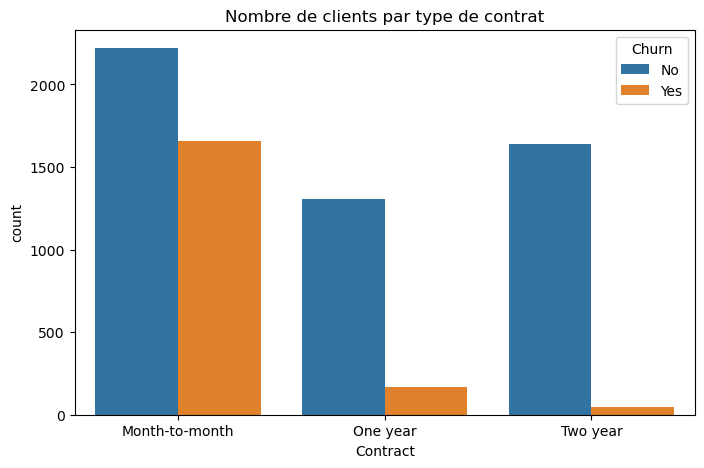

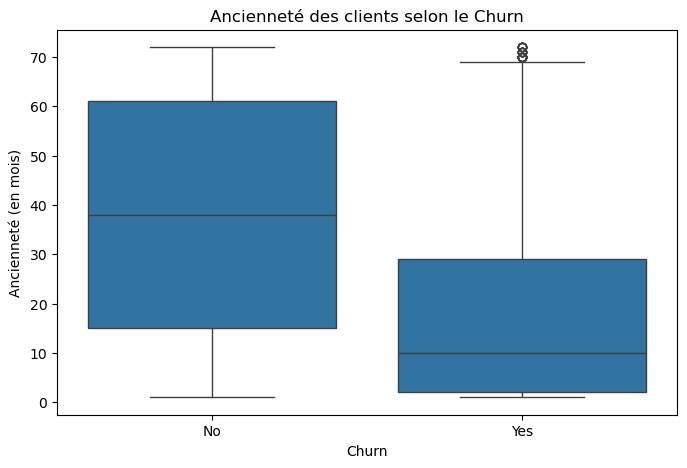

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Churn vs Type de Contrat (Countplot : compte le nombre de personnes)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Nombre de clients par type de contrat')
plt.show()

# 2. Churn vs Ancienneté (Boxplot : montre la moyenne et la répartition)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Ancienneté des clients selon le Churn')
plt.ylabel('Ancienneté (en mois)')
plt.show()

**Contrat vs churn**

On observe que les clients avec un contrat mensuel ("Month-to-month") churnent beaucoup plus que ceux avec un contrat à long terme.

Cela suggère que l’engagement contractuel joue un rôle important dans la fidélisation.

**Ancienneté vs churn**

Les clients qui churnent ont en moyenne une ancienneté plus faible.

Cela indique que les nouveaux clients sont plus susceptibles de quitter l’entreprise, ce qui peut traduire un problème d’onboarding ou de satisfaction initiale.

On observe également quelques valeurs extrêmes, mais elles restent plausibles dans le contexte métier et ne sont pas supprimées.

### Analyse de variables catégorielles supplémentaires

Nous complétons l’analyse en étudiant d’autres variables catégorielles susceptibles d’être liées au churn, notamment le type de service internet et le mode de paiement.

In [7]:
# Taux de churn selon InternetService
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print("Taux de churn selon InternetService :")
display(internet_churn)

# Taux de churn selon PaymentMethod
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
print("Taux de churn selon PaymentMethod :")
display(payment_churn)

Taux de churn selon InternetService :


Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


Taux de churn selon PaymentMethod :


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


On observe que certaines catégories présentent un taux de churn plus élevé que d’autres.

Le type de service internet et le mode de paiement semblent donc avoir une influence sur le risque de départ.

Ces variables catégorielles pourront être utiles dans la modélisation supervisée après encodage.

## 7. Analyse des corrélations

La matrice de corrélation permet d’identifier les relations entre variables numériques.

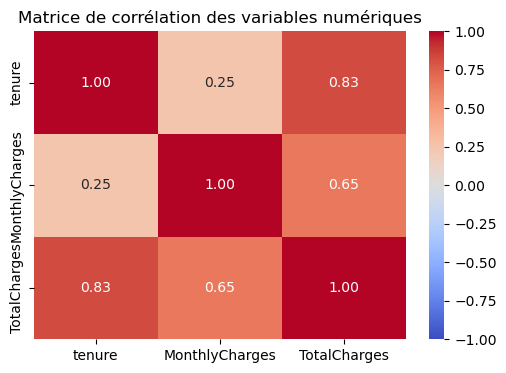

In [8]:
# Sélection des variables numériques
cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Calcul de la matrice de corrélation
corr_matrix = df[cols_num].corr()

# Affichage avec une Heatmap 
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice de corrélation des variables numériques')
plt.show()

On observe une forte corrélation entre `tenure` et `TotalCharges`, ce qui est logique puisque les charges totales augmentent avec le temps.

Ces informations sont utiles pour comprendre les relations entre variables mais ne suffisent pas à expliquer directement le churn.

## 8. Conclusion de l’EDA

Cette analyse exploratoire met en évidence plusieurs éléments importants :

- les clients récents churnent davantage ;
- les contrats mensuels sont associés à un taux de churn plus élevé ;
- certaines variables comme les charges et l’ancienneté sont fortement liées entre elles.

Ces observations guideront les étapes suivantes :
- le preprocessing des données ;
- le choix des variables ;
- la modélisation supervisée et non supervisée.

## 9. Modélisation supervisée

L’objectif est de prédire si un client va churner à partir de ses caractéristiques.

Nous utilisons une pipeline incluant :
- le preprocessing (standardisation + encodage)
- un modèle de régression logistique

Cette approche permet de garantir la cohérence entre entraînement et prédiction.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Séparation Features (X) / Target (y)
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

# 2. Encodage de la Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

### Séparation des données

Nous séparons les données en :
- ensemble d’entraînement (80%)
- ensemble de test (20%)

La stratification est utilisée pour conserver la proportion de churn dans les deux ensembles.

In [10]:
# 3. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### Pipeline de preprocessing

Nous appliquons :
- StandardScaler sur les variables numériques
- OneHotEncoder sur les variables catégorielles

Cela permet de préparer correctement les données pour le modèle.

### Évaluation du modèle

Nous évaluons les performances à l’aide des métriques :
- précision
- recall
- F1-score

Dans un contexte de churn, le recall est particulièrement important car il permet d’identifier un maximum de clients à risque.

In [11]:
# 4. Création de la pipeline de preprocessing
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# 5. Création du modèle complet (preprocessing + régression logistique)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 6. Entraînement sur X_train et prédiction sur X_test
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

# 7. Évaluation et affichage des métriques
print("--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

No Churn (0)       0.85      0.88      0.87      1033
   Churn (1)       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



Le modèle atteint une accuracy de 80%, ce qui est correct.

Cependant, le recall sur la classe churn (56%) reste limité.
Cela signifie que le modèle ne détecte qu’un peu plus de la moitié des clients qui vont réellement partir.

Dans un contexte business, cela peut être problématique car certains clients à risque ne seront pas identifiés.

Des améliorations sont possibles :
- tester d’autres modèles (Random Forest, Gradient Boosting)
- ajuster les paramètres
- travailler sur l’équilibrage des classes

### Matrice de confusion

La matrice de confusion permet d’analyser en détail les performances du modèle en distinguant :
- les bonnes prédictions
- les erreurs de classification

On observe notamment le nombre de clients churn correctement détectés et ceux qui ne le sont pas.

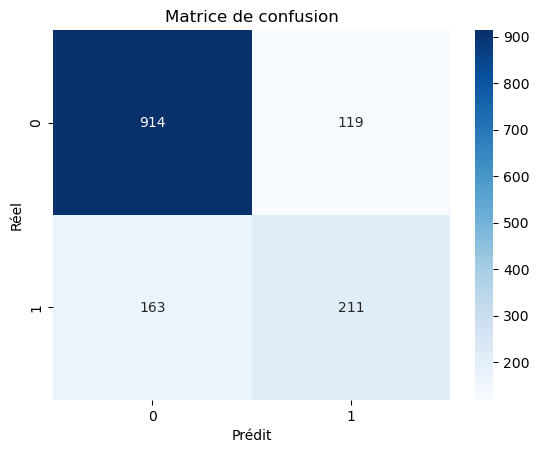

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [13]:
import joblib
import os

# Création du dossier models s'il n'existe pas
os.makedirs('models', exist_ok=True)

# Sauvegarde de la pipeline complète (preprocessing + modèle)
joblib.dump(model_pipeline, 'models/model.pkl')

print("Modèle sauvegardé avec succès dans le dossier 'models/' !")

Modèle sauvegardé avec succès dans le dossier 'models/' !


## 10. Modélisation non supervisée (clustering)

L’objectif est de segmenter les clients en groupes homogènes afin de mieux comprendre les profils de churn.

Nous utilisons l’algorithme K-Means sur les variables numériques. On choisit 3 clusters pour simplifier l’analyse et obtenir une segmentation lisible.

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. On sélectionne uniquement les variables numériques pour faire nos groupes
X_num = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# 2. On remet toutes les valeurs à la même échelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# 3. Création de l'algorithme K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 4. On entraîne et on attribue immédiatement un numéro de groupe à chaque client
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Analyse business des groupes
# On calcule la moyenne de chaque variable pour comprendre qui est dans quel groupe
cluster_summary = df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
cluster_summary['Nombre_Clients'] = df['Cluster'].value_counts()

# On regarde si certains groupes ont naturellement plus tendance à résilier
cluster_summary['Taux_Churn_Reel (%)'] = df.groupby('Cluster')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

print("PROFIL DES CLUSTERS (SEGMENTATION)")
display(cluster_summary.round(2))

--- PROFIL DES CLUSTERS (SEGMENTATION) ---


,tenure,MonthlyCharges,TotalCharges,Nombre_Clients,Taux_Churn_Reel (%)
Cluster,,,,,
0,29.62,26.63,815.26,2151,12.32
1,58.57,89.74,5249.43,2197,15.38
2,13.26,74.97,1031.88,2684,47.17


### Interprétation du clustering

L’analyse des clusters montre que certains groupes présentent un taux de churn plus élevé.

On observe notamment qu’un cluster regroupe des clients avec :
- une faible ancienneté ;
- des charges relativement élevées.

Ces clients semblent plus à risque de quitter l’entreprise.

À l’inverse, les clients avec une ancienneté plus élevée apparaissent plus fidèles.

Cette segmentation permet d’identifier des profils types et complète l’approche supervisée. 

Ces résultats peuvent être utilisés pour cibler des actions marketing spécifiques selon les profils de clients.

## 11. Conclusion

Ce projet a permis de :
- comprendre les facteurs liés au churn grâce à l’EDA
- construire un modèle prédictif
- segmenter les clients via le clustering

Le modèle supervisé donne des résultats corrects mais perfectibles, notamment sur la détection des clients à risque.

Le clustering apporte une vision complémentaire en identifiant des profils de clients distincts.

Ces résultats peuvent être exploités pour améliorer la fidélisation client.